# Evaluation: **FULL** vs **PARTIAL (best-of)**

This notebook contains the evaluation of the results generated by `evaluate_full_vs_partial_templates.py`.


## Step 1 – Setup & Paths
Define the **base output directory** and the **item**. If you want to analyze multiple items, you can run the cell multiple times or use a loop.

In [1]:
# Imports (keep it lightweight)
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

# === User-configurable paths ===
# Set the base directory that contains per-item folders like 'apple/full/results.csv' etc.
SOURCE_DIR = Path("../results/evaluate_full_vs_partial_templates")
ANALYSIS_DIR = Path(SOURCE_DIR) / "analysis"
ITEM = "banana"  # <- passe an: z.B. "apple", "banana", "orange", "bottle"

assert SOURCE_DIR.exists(), f"Quellverzeichnis nicht gefunden: {SOURCE_DIR}"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("SOURCE_DIR:", SOURCE_DIR.resolve())
print("ANALYSIS_DIR:", ANALYSIS_DIR.resolve())
print("ITEM:", ITEM)

SOURCE_DIR: /home/jonathan/Workspace/Bachelor/Bachelor-Code/results/evaluate_full_vs_partial_templates
ANALYSIS_DIR: /home/jonathan/Workspace/Bachelor/Bachelor-Code/results/evaluate_full_vs_partial_templates/analysis
ITEM: banana


## Step 2 – Load data & sanity checks
The runner scripts either write a **combined** file `results_combined.csv` per item,
or separate files `full/results.csv` and `partial_all/results.csv`. 
It is prefered to load the combined file.


In [ ]:
def load_results_for_item(source_dir: Path, item: str) -> pd.DataFrame:
    """Load combined results if available; otherwise join full/partial manually."""
    item_dir = source_dir / item
    f_combined = item_dir / "results_combined.csv"
    f_full = item_dir / "full" / "results.csv"
    f_part = item_dir / "partial_all" / "results.csv"

    if f_combined.exists():
        df = pd.read_csv(f_combined)
    else:
        dfs = []
        if f_full.exists():
            df_full = pd.read_csv(f_full).copy()
            df_full["condition"] = "full"
            dfs.append(df_full)
        if f_part.exists():
            df_part = pd.read_csv(f_part).copy()
            df_part["condition"] = "partial_best"
            dfs.append(df_part)
        if not dfs:
            raise FileNotFoundError("Whether combined nor separate CSVs found.")
        df = pd.concat(dfs, ignore_index=True)

    # Canonicalize common columns (aliases left intact)
    col_map = {
        "inlier_rmse": ["inlier_rmse", "inlier-rmse", "inlier__rmse", "rmse"],
        "fitness": ["fitness"],
        "translation_error": ["translation_error", "trans_err", "t_error", "translation__error"],
        "rotation_error": ["rotation_error", "rot_err", "r_error", "rotation__error"],
        "runtime_s": ["runtime_s", "runtime", "time_s", "t_s"],
        "correspondence_set_size": ["correspondence_set_size", "corr_size", "num_inliers"],
    }
    for canon, candidates in col_map.items():
        if canon not in df.columns:
            for c in candidates:
                if c in df.columns:
                    df[canon] = df[c]
                    break
    return df

df = load_results_for_item(SOURCE_DIR, ITEM)
print(df["condition"].value_counts(dropna=False))
df

condition
full            160
partial_best    160
Name: count, dtype: int64


,dataset_id,template,fitness,inlier_rmse,translation_error,rotation_error,correspondence_set_size,transformation,duration,condition
0,301,full_model,0.258824,0.013058,0.027377,58.503904,22,"[[0.9955058520212775, -0.00037605508238987517,...",0.107485,full
1,302,full_model,0.305882,0.012067,0.078590,88.172742,26,"[[0.3622205466181126, -0.8961450033075226, -0....",0.065637,full
2,303,full_model,0.294118,0.012444,0.019808,43.531854,25,"[[0.9560450067568651, 0.21879170368508347, 0.1...",0.061677,full
3,304,full_model,0.235294,0.013326,0.030037,178.767868,20,"[[0.9624082682368318, 0.19649730533823817, 0.1...",0.064500,full
4,305,full_model,0.164706,0.011979,0.067603,123.215454,14,"[[-0.41889275877550863, -0.22058831910378257, ...",0.066487,full
...,...,...,...,...,...,...,...,...,...,...
315,494,banana_template_011_az72_el0.ply,1.000000,0.009980,0.067195,130.564887,18,"[[0.9155303174106698, 0.22108294644377086, -0....",0.017161,partial_best
316,495,banana_template_011_az72_el0.ply,0.888889,0.009236,0.140125,174.208609,16,"[[0.39570531336350534, -0.9018105674816842, -0...",0.046384,partial_best
317,496,banana_template_011_az72_el0.ply,0.944444,0.011591,0.057899,145.854380,17,"[[0.8609052531761238, 0.10096957973669461, -0....",0.018038,partial_best
318,498,banana_template_011_az72_el0.ply,1.000000,0.009037,0.072468,165.818279,18,"[[0.9699126084352567, 0.23304755514222383, 0.0...",0.015666,partial_best


Step 3 – Basic statistics per condition
Quick metrics for `full` vs. `partial_best`.


In [ ]:
# Basic sanity checks on ranges and NaN
expected_cols = ["condition", "fitness", "inlier_rmse", "runtime_s"]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    print("Warning – missing expected columns:", missing)

print("\nNaN proportions (top 12 columns):")
print(df.isna().mean().sort_values(ascending=False).head(12))

print("\nfitness area:", float(df.get("fitness", pd.Series([np.nan])).min()), "→",
      float(df.get("fitness", pd.Series([np.nan])).max()))
print("Inlier-RMSE area:", float(df.get("inlier_rmse", pd.Series([np.nan])).min()), "→",
      float(df.get("inlier_rmse", pd.Series([np.nan])).max()))
print("Runtime [s] area:", float(df.get("runtime_s", pd.Series([np.nan])).min()), "→",
      float(df.get("runtime_s", pd.Series([np.nan])).max()))

def summarize_by_condition(df: pd.DataFrame, cols=("fitness", "inlier_rmse", "runtime_s")) -> pd.DataFrame:
    """Return per-condition summary (count, mean, median, std)."""
    groups = df.groupby("condition", dropna=False)
    pieces = []
    for cond, g in groups:
        summary = {"condition": cond, "n": len(g)}
        for c in cols:
            if c in g.columns:
                x = g[c].astype(float)
                summary[f"{c}__mean"] = x.mean()
                summary[f"{c}__median"] = x.median()
                summary[f"{c}__std"] = x.std(ddof=1)
        pieces.append(summary)
    return pd.DataFrame(pieces)

summary = summarize_by_condition(df)
summary


Warnung – fehlende erwartete Spalten: ['runtime_s']

NaN-Anteile (Top 12 Spalten):
dataset_id                 0.0
template                   0.0
fitness                    0.0
inlier_rmse                0.0
translation_error          0.0
rotation_error             0.0
correspondence_set_size    0.0
transformation             0.0
duration                   0.0
condition                  0.0
dtype: float64

Fitness-Bereich: 0.1058823529411764 → 1.0
Inlier-RMSE-Bereich: 0.0078638808442493 → 0.0152036743149987
Runtime [s]-Bereich: nan → nan


,condition,n,fitness__mean,fitness__median,fitness__std,inlier_rmse__mean,inlier_rmse__median,inlier_rmse__std
0,full,160,0.231250,0.223529,0.055355,0.012747,0.012733,0.000833
1,partial_best,160,0.865073,0.888889,0.142686,0.010589,0.010553,0.001234


<Figure size 640x480 with 0 Axes>

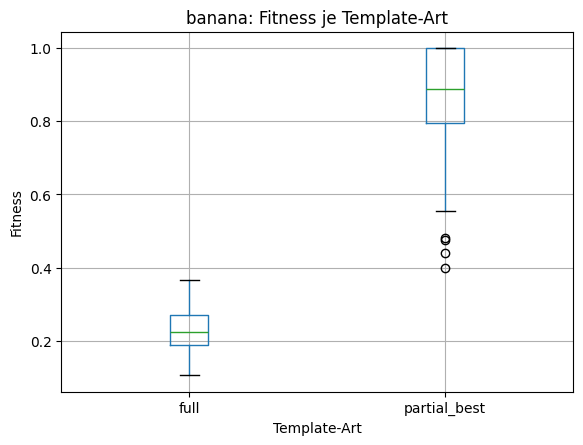

<Figure size 640x480 with 0 Axes>

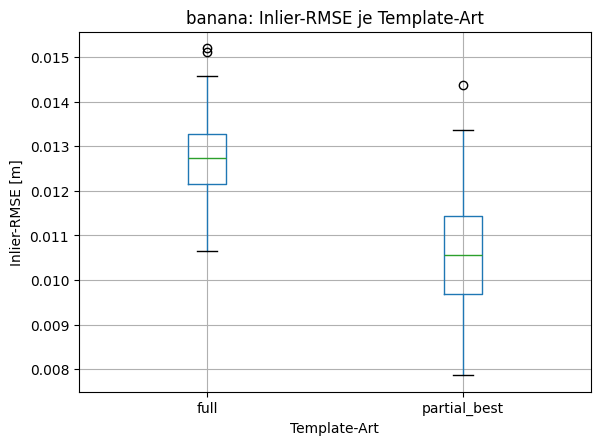

In [ ]:
# First simple plots (one metric at a time)
plt.figure()
df.boxplot(column=["fitness"], by="condition")
plt.title(f"{ITEM}: fitness per template type")
plt.suptitle("")
plt.xlabel("template type")
plt.ylabel("fitness")
plt.show()

plt.figure()
df.boxplot(column=["inlier_rmse"], by="condition")
plt.title(f"{ITEM}: Inlier-RMSE per template type")
plt.suptitle("")
plt.xlabel("template type")
plt.ylabel("Inlier-RMSE [m]")
plt.show()


## Step 4 – Pairwise comparison per scene (FULL vs. PARTIAL)

We pair **FULL** and **PARTIAL (best-of)** per scene and calculate **differences**,
e.g., ΔFitness = Fitness_partial − Fitness_full.


In [ ]:
def guess_id_column(columns) -> str | None:
    """Guess an ID column that identifies the scene/sample."""
    candidates = ["scene_id", "sample_id", "id", "dataset_id", "frame_id"]
    for c in candidates:
        if c in columns:
            return c
    return None

id_col = guess_id_column(df.columns)
print("found ID column:", id_col)

if id_col is None:
    raise RuntimeError("No ID column detected. Please add/name a unique scene ID in the CSVs.")

full = df[df["condition"] == "full"].copy()
part = df[df["condition"] == "partial_best"].copy()
paired = full.merge(part, on=id_col, how="inner", suffixes=("__full", "__partial"))
print("Gepaart:", paired.shape)
paired.head(3)


Gefundene ID-Spalte: dataset_id
Gepaart: (160, 19)


,dataset_id,template__full,fitness__full,inlier_rmse__full,translation_error__full,rotation_error__full,correspondence_set_size__full,transformation__full,duration__full,condition__full,template__partial,fitness__partial,inlier_rmse__partial,translation_error__partial,rotation_error__partial,correspondence_set_size__partial,transformation__partial,duration__partial,condition__partial
0,301,full_model,0.258824,0.013058,0.027377,58.503904,22,"[[0.9955058520212775, -0.00037605508238987517,...",0.107485,full,banana_template_016_az72_el30.ply,0.840000,0.008817,0.115494,109.022641,21,"[[-0.8452517554469755, 0.3617734856700097, 0.3...",0.018508,partial_best
1,302,full_model,0.305882,0.012067,0.078590,88.172742,26,"[[0.3622205466181126, -0.8961450033075226, -0....",0.065637,full,banana_template_011_az72_el0.ply,0.944444,0.011460,0.137864,84.847200,17,"[[0.9045200952718703, 0.40492142062143743, -0....",0.031880,partial_best
2,303,full_model,0.294118,0.012444,0.019808,43.531854,25,"[[0.9560450067568651, 0.21879170368508347, 0.1...",0.061677,full,banana_template_016_az72_el30.ply,0.920000,0.011975,0.132104,166.329052,23,"[[-0.8358834026325213, -0.461465124411732, 0.2...",0.074080,partial_best


## Step 5 – Δ values & improvement percentages

Calculation of Δ metrics and percentages of scenes with improvement (e.g., lower RMSE).


In [ ]:
def add_deltas(paired_df: pd.DataFrame, metrics=("fitness","inlier_rmse","runtime_s","correspondence_set_size")):
    """Compute deltas partial - full for all metrics that exist, return (df_with_deltas, available_delta_cols)."""
    m = paired_df.copy()
    available = []
    for name in metrics:
        p = f"{name}__partial"
        f = f"{name}__full"
        if p in m.columns and f in m.columns:
            dname = f"delta_{name}"
            m[dname] = m[p].astype(float) - m[f].astype(float)
            available.append(dname)
    return m, available

# Build paired frame first (wie gehabt)
def guess_id_column(columns) -> str | None:
    for c in ["scene_id","sample_id","id","dataset_id","frame_id"]:
        if c in columns: return c
    return None

id_col = guess_id_column(df.columns)
if not id_col:
    raise RuntimeError("No ID column detected. Please name a unique scene ID.")

full = df[df["condition"]=="full"].copy()
part = df[df["condition"]=="partial_best"].copy()
paired = full.merge(part, on=id_col, how="inner", suffixes=("__full","__partial"))

paired, delta_cols = add_deltas(paired)
print("Δ-Spalten:", delta_cols)
paired[delta_cols].describe().T if delta_cols else print("No Δ columns generated (missing original columns).")


Δ-Spalten: ['delta_fitness', 'delta_inlier_rmse', 'delta_correspondence_set_size']


,count,mean,std,min,25%,50%,75%,max
delta_fitness,160.0,0.633823,0.141585,0.247059,0.540196,0.665359,0.745261,0.858824
delta_inlier_rmse,160.0,-0.002157,0.001543,-0.005416,-0.003323,-0.002189,-0.001029,0.001282
delta_correspondence_set_size,160.0,-2.856250,4.086866,-15.000000,-5.000000,-2.000000,0.000000,6.000000


In [7]:
def improvement_share(x: pd.Series, better_when="higher"):
    """Return share of scenes with improvement given directionality."""
    x = x.dropna()
    if better_when == "higher":
        return (x > 0).mean()
    else:
        return (x < 0).mean()

summary_impr = {
    "fitness_improved_share": improvement_share(paired.get("delta_fitness", pd.Series(dtype=float)), "higher"),
    "inlier_rmse_improved_share": improvement_share(paired.get("delta_inlier_rmse", pd.Series(dtype=float)), "lower"),
    "runtime_improved_share": improvement_share(paired.get("delta_runtime_s", pd.Series(dtype=float)), "lower"),
}
pd.Series(summary_impr)


fitness_improved_share        1.00000
inlier_rmse_improved_share    0.90625
runtime_improved_share            NaN
dtype: float64

## Step 6 – Effect sizes (Cohen's d<sub>z</sub>) & (optional) Wilcoxon

Cohen's d<sub>z</sub> is suitable for paired differences. A Wilcoxon signed-rank test is
automatically attempted (if SciPy is available).


In [ ]:
def cohens_dz(diff: np.ndarray) -> float:
    """Cohen's dz for paired differences."""
    diff = diff[~np.isnan(diff)]
    if diff.size == 0:
        return np.nan
    return float(np.mean(diff) / (np.std(diff, ddof=1) if diff.size > 1 else np.nan))

dz_fitness = cohens_dz(paired.get("delta_fitness", pd.Series(dtype=float)).to_numpy())
dz_rmse    = cohens_dz(paired.get("delta_inlier_rmse", pd.Series(dtype=float)).to_numpy())
dz_runtime = cohens_dz(paired.get("delta_runtime_s", pd.Series(dtype=float)).to_numpy())
print({"dz_fitness": dz_fitness, "dz_inlier_rmse": dz_rmse, "dz_runtime": dz_runtime})

# Optional: Wilcoxon signed-rank, falls SciPy verfügbar
try:
    from scipy.stats import wilcoxon
    def safe_wilcoxon(d):
        d = pd.Series(d).dropna()
        if len(d) == 0:
            return np.nan, np.nan
        # zero_method='wilcox' ignores zeros
        stat, p = wilcoxon(d, zero_method='wilcox')
        return float(stat), float(p)

    w_fitness = safe_wilcoxon(paired.get("delta_fitness", pd.Series(dtype=float)))
    w_rmse    = safe_wilcoxon(paired.get("delta_inlier_rmse", pd.Series(dtype=float)))
    w_runtime = safe_wilcoxon(paired.get("delta_runtime_s", pd.Series(dtype=float)))
    print({"wilcoxon_fitness": w_fitness, "wilcoxon_inlier_rmse": w_rmse, "wilcoxon_runtime": w_runtime})
except Exception:
    print("SciPy not available – Wilcoxon test omitted.")


{'dz_fitness': 4.476643777859398, 'dz_inlier_rmse': -1.3977522823681532, 'dz_runtime': nan}
{'wilcoxon_fitness': (0.0, 5.211233789492337e-28), 'wilcoxon_inlier_rmse': (289.0, 1.0771165696253698e-25), 'wilcoxon_runtime': (nan, nan)}


## Step 7 – Visualizations

Histograms of the Δ values and scatter plots of FULL vs. PARTIAL with identity line.


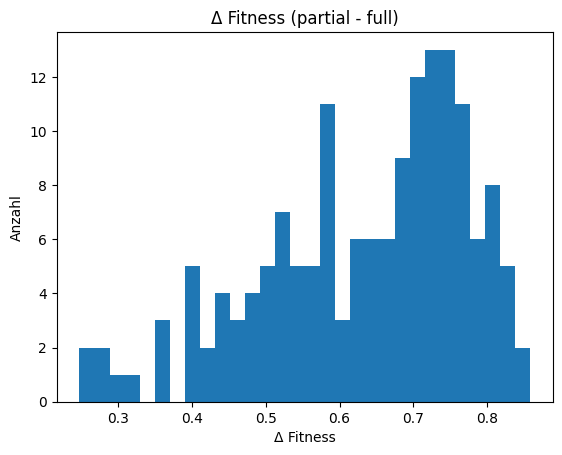

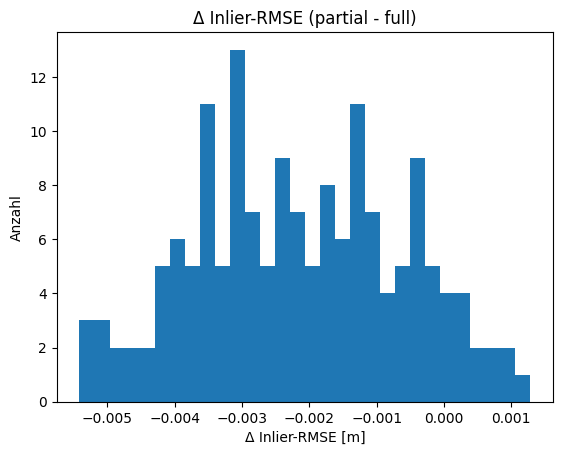

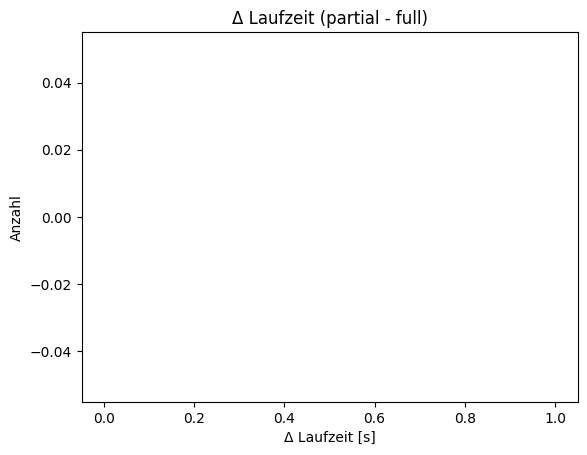

In [ ]:
def hist_delta(series, title, xlabel):
    s = pd.Series(series).dropna()
    plt.figure()
    plt.hist(s, bins=30)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Anzahl")
    plt.show()

hist_delta(paired.get("delta_fitness", pd.Series(dtype=float)), "Δ Fitness (partial - full)", "Δ Fitness")
hist_delta(paired.get("delta_inlier_rmse", pd.Series(dtype=float)), "Δ Inlier-RMSE (partial - full)", "Δ Inlier-RMSE [m]")
hist_delta(paired.get("delta_runtime_s", pd.Series(dtype=float)), "Δ runtime (partial - full)", "Δ runtime [s]")


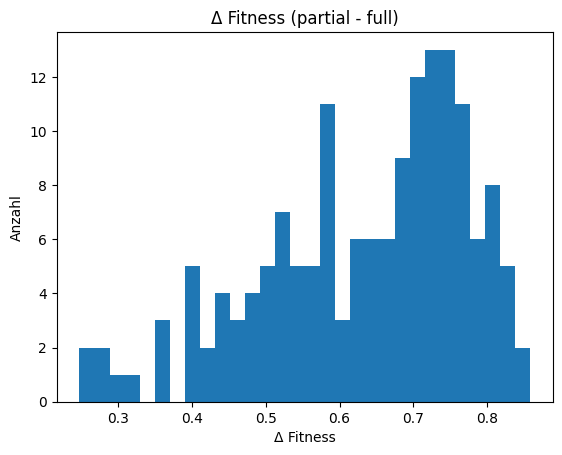

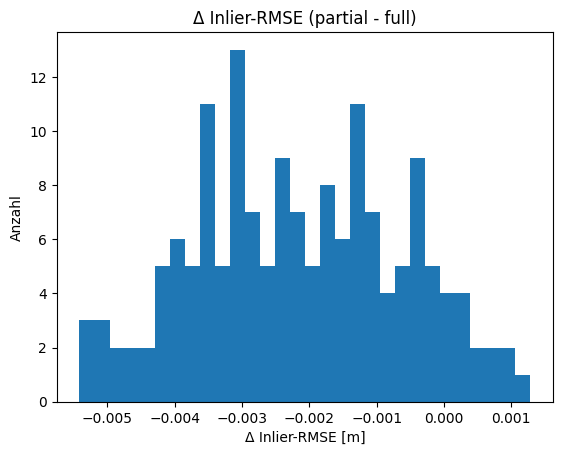

[skip] delta_runtime_s fehlt.


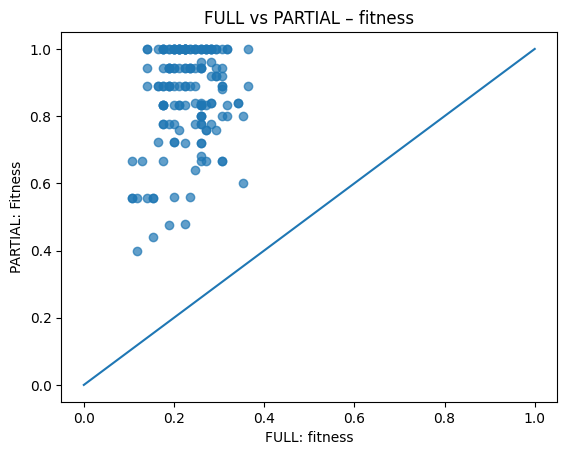

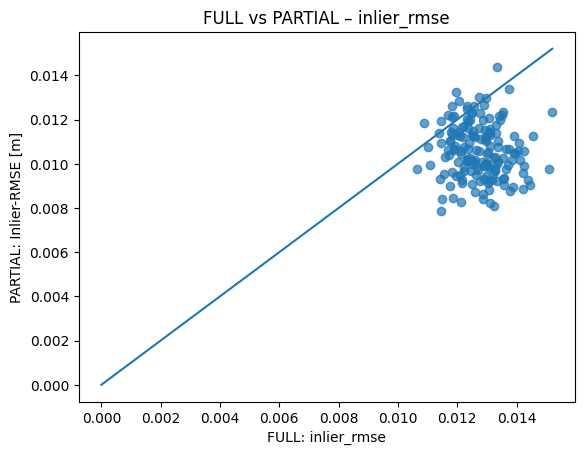

[skip] runtime_s: erforderliche Spalten fehlen.


In [10]:
def hist_delta_safe(df: pd.DataFrame, col: str, title: str, xlabel: str):
    if col not in df.columns:
        print(f"[skip] {col} fehlt.")
        return
    s = pd.Series(df[col]).dropna()
    plt.figure()
    plt.hist(s, bins=30)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("Anzahl")
    plt.show()

def scatter_full_vs_partial_safe(paired_df: pd.DataFrame, metric: str, ylabel: str):
    y = f"{metric}__partial"; x = f"{metric}__full"
    if y not in paired_df.columns or x not in paired_df.columns:
        print(f"[skip] {metric}: erforderliche Spalten fehlen.")
        return
    plt.figure()
    plt.scatter(paired_df[x], paired_df[y], alpha=0.7)
    mn = float(min(pd.concat([paired_df[x], paired_df[y]]).min(), 0))
    mx = float(pd.concat([paired_df[x], paired_df[y]]).max())
    plt.plot([mn, mx], [mn, mx])  # identity line
    plt.xlabel(f"FULL: {metric}")
    plt.ylabel(f"PARTIAL: {ylabel}")
    plt.title(f"FULL vs PARTIAL – {metric}")
    plt.show()

# Beispiele:
hist_delta_safe(paired, "delta_fitness", "Δ Fitness (partial - full)", "Δ Fitness")
hist_delta_safe(paired, "delta_inlier_rmse", "Δ Inlier-RMSE (partial - full)", "Δ Inlier-RMSE [m]")
hist_delta_safe(paired, "delta_runtime_s", "Δ Laufzeit (partial - full)", "Δ Laufzeit [s]")

scatter_full_vs_partial_safe(paired, "fitness", "Fitness")
scatter_full_vs_partial_safe(paired, "inlier_rmse", "Inlier-RMSE [m]")
scatter_full_vs_partial_safe(paired, "runtime_s", "Laufzeit [s]")


## Step 8 – Exports

Export the paired data, a compact summary, and a LaTeX table.


In [ ]:
# Build per-item analysis folder (separate from SOURCE)
OUT_ITEM_DIR = ANALYSIS_DIR / ITEM
OUT_ITEM_DIR.mkdir(parents=True, exist_ok=True)

# Save paired (robust)
paired_csv = OUT_ITEM_DIR / "paired_full_vs_partial.csv"
paired.to_csv(paired_csv, index=False)
print("Paired CSV saved:", paired_csv)

# Build summary only from existing delta columns
def build_summary_from_available(paired_df: pd.DataFrame, deltas: list[str]) -> pd.DataFrame:
    rows = []
    for dcol in deltas:
        metric = dcol.replace("delta_","")
        s = pd.Series(paired_df.get(dcol, pd.Series(dtype=float))).dropna()
        if s.empty:
            continue
        # Direction: higher is better for fitness, lower is better for RMSE/Runtime
        better_when = "higher" if metric == "fitness" else "lower"
        improved_share = float((s > 0).mean()) if better_when == "higher" else float((s < 0).mean())
        # Cohen's dz
        dz = float(s.mean() / (s.std(ddof=1) if len(s)>1 else np.nan))
        rows.append({
            "metric": metric,
            "delta_mean": float(s.mean()),
            "delta_median": float(s.median()),
            "improved_share": improved_share,
            "cohens_dz": dz,
        })
    return pd.DataFrame(rows, columns=["metric","delta_mean","delta_median","improved_share","cohens_dz"])

summary_df = build_summary_from_available(paired, delta_cols)
summary_csv = OUT_ITEM_DIR / "paired_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("Summary saved:", summary_csv)

# LaTeX only if we have content
if not summary_df.empty:
    latex_path = OUT_ITEM_DIR / "paired_summary.tex"
    latex = summary_df.to_latex(index=False, float_format=lambda x: f"{x:.3f}")
    latex_path.write_text(latex, encoding="utf-8")
    print("LaTeX table saved:", latex_path)
else:
    print("[info] No Δ metrics available – LaTeX output skipped.")


Gepaartes CSV gespeichert: ../results/evaluate_full_vs_partial_templates/analysis/banana/paired_full_vs_partial.csv
Zusammenfassung gespeichert: ../results/evaluate_full_vs_partial_templates/analysis/banana/paired_summary.csv
LaTeX-Tabelle gespeichert: ../results/evaluate_full_vs_partial_templates/analysis/banana/paired_summary.tex


## Additional plots: translation errors, rotation errors, and number of inliers

The following box plots show the distributions per **template type** (`full` vs. `partial_best`) for:
- Translation error \(e_t\) \([m]\),
- Rotation error \(e_r\) \([\degree]\),
- Number of inliers (correspondence set size).


<Figure size 640x480 with 0 Axes>

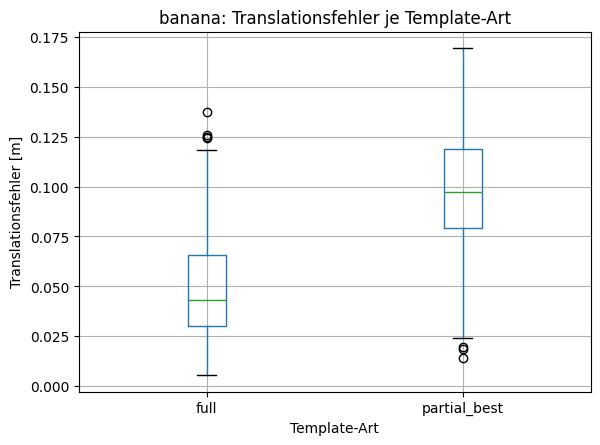

<Figure size 640x480 with 0 Axes>

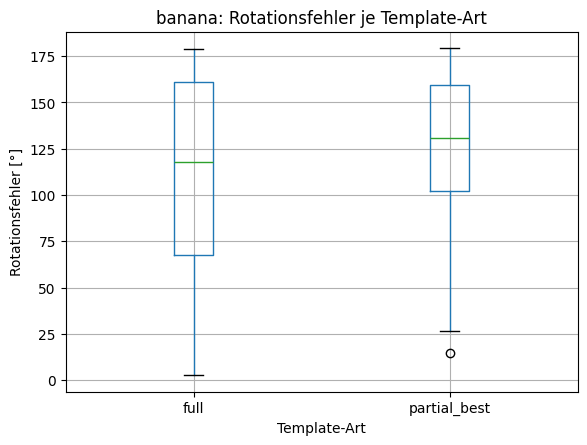

<Figure size 640x480 with 0 Axes>

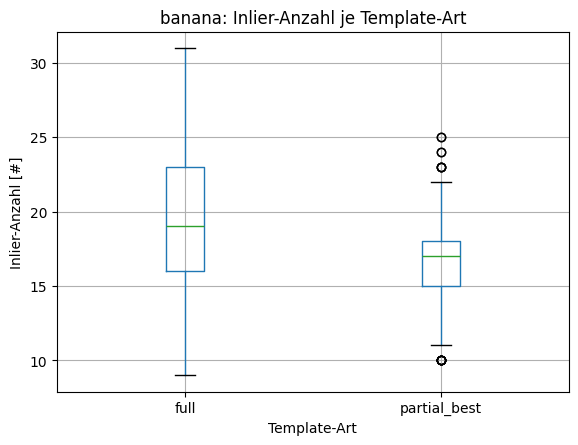

In [ ]:
# Helper to draw a boxplot by condition if column exists
def boxplot_by_condition_safe(df: pd.DataFrame, col: str, title: str, ylabel: str):
    """Draw a pandas boxplot grouped by 'condition' if column is present."""
    if "condition" not in df.columns:
        print("[skip] 'condition' column missing.")
        return
    if col not in df.columns:
        print(f"[skip] '{col}' not found; available columns: {list(df.columns)}")
        return
    plt.figure()
    # Use pandas GroupBy.boxplot-like API via DataFrame.boxplot
    df.boxplot(column=[col], by="condition")
    plt.title(title)
    plt.suptitle("")  # remove automatic super title
    plt.xlabel("Template-Art")  # german axis name
    plt.ylabel(ylabel)
    plt.show()

# --- Box-Plots ---
# Translationsfehler [m] (expects 'translation_error' in meters)
boxplot_by_condition_safe(
    df, "translation_error",
    title=f"{ITEM}: translation error per template type",
    ylabel="translation error [m]"
)

# Rotationsfehler [°] (expects 'rotation_error' in degrees)
boxplot_by_condition_safe(
    df, "rotation_error",
    title=f"{ITEM}: rotation error error per template type",
    ylabel="rotation error [°]"
)

# Inlier-Anzahl / Correspondence Set Size (counts)
boxplot_by_condition_safe(
    df, "correspondence_set_size",
    title=f"{ITEM}: inlier count per template type",
    ylabel="inlier count [#]"
)
